In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


loading dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving application_train.csv to application_train.csv


In [3]:
import os

base_path = "/content/drive/MyDrive/code_alpha"

folders = [
    "models",
    "outputs",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [4]:
import os

print(os.listdir("/content/drive/MyDrive/code_alpha"))

['application_train.csv.zip', 'models', 'outputs', 'notebooks']


In [5]:
import pandas as pd

df = pd.read_csv("application_train.csv")

print(df.shape)

(307511, 122)


In [6]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [9]:
df['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,91.927118
1,8.072882


In [8]:
df['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


missing values

In [10]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing = missing.sort_values(ascending=False)

print(missing.head(20))

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64


In [11]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent.sort_values(
    ascending=False
)

print(missing_percent.head(20))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


In [12]:
missing_percent.to_csv(
    "/content/drive/MyDrive/code_alpha/outputs/missing_values_report.csv"
)

In [13]:
missing_percent.head(20)

,0
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


In [14]:
missing_percent = (df.isnull().sum() / len(df)) * 100

cols_to_drop = missing_percent[missing_percent > 50].index

print(f"Columns to drop: {len(cols_to_drop)}")

Columns to drop: 41


In [15]:
df = df.drop(columns=cols_to_drop)

print(df.shape)

(307511, 81)


Fill Remaining Missing Values

In [16]:
for col in df.columns:

    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_4043/2513339156.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_4043/2513339156.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.dtypes.value_counts()

,count
int64,41
float64,27
object,13


In [19]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:", len(categorical_cols))

Categorical Columns: 13


Encode Categorical Columns

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

print("Encoding Complete")

Encoding Complete


In [21]:
df.dtypes.value_counts()

,count
int64,54
float64,27


outlier handling

In [22]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

numerical_cols = [col for col in numerical_cols if col != 'TARGET']

print(len(numerical_cols))

80


In [23]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)

print("Outlier treatment completed")

Outlier treatment completed


In [24]:
important_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY'
]

df[important_cols].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
count,307511.000000,3.075110e+05,307511.000000
mean,162626.947877,5.923130e+05,26797.657150
std,73303.150927,3.803162e+05,13281.285661
min,25650.000000,4.500000e+04,1615.500000
25%,112500.000000,2.700000e+05,16524.000000
50%,147150.000000,5.135310e+05,24903.000000
75%,202500.000000,8.086500e+05,34596.000000
max,337500.000000,1.616625e+06,61704.000000


In [25]:
df.to_csv(
    '/content/drive/MyDrive/code_alpha/outputs/cleaned_credit_data.csv',
    index=False
)

encode Categorical Columns

In [26]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

print("Encoding Complete")

Encoding Complete


In [27]:
df.select_dtypes(include=['object']).shape

(307511, 0)

Feature Engineering

In [30]:
df['INCOME_CREDIT_RATIO'] = df['AMT_INCOME_TOTAL'] / (df['AMT_CREDIT'] + 1)

df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

df['EMPLOYED_BIRTH_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)

df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / (df['AMT_ANNUITY'] + 1)

df['INCOME_PER_FAMILY_MEMBER'] = (
    df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
)

df['CHILDREN_RATIO'] = (
    df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)
)

In [31]:
print(df.shape)

(307511, 87)


Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(246008, 86)
(61503, 86)


Check Class Imbalance

In [33]:
print(y.value_counts())

print(y.value_counts(normalize=True) * 100)

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Train Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

Evaluate Logistic Regression

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC AUC  :", roc_auc_score(y_test, lr_prob))

Accuracy : 0.6859015007398013
Precision: 0.15879807920886227
Recall   : 0.6727089627391742
F1 Score : 0.2569428417570582
ROC AUC  : 0.7407049031928441


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



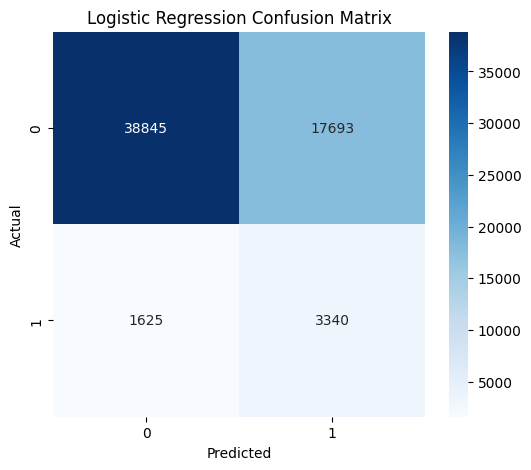

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.savefig(
    '/content/drive/MyDrive/code_alpha/outputs/lr_confusion_matrix.png'
)

plt.show()

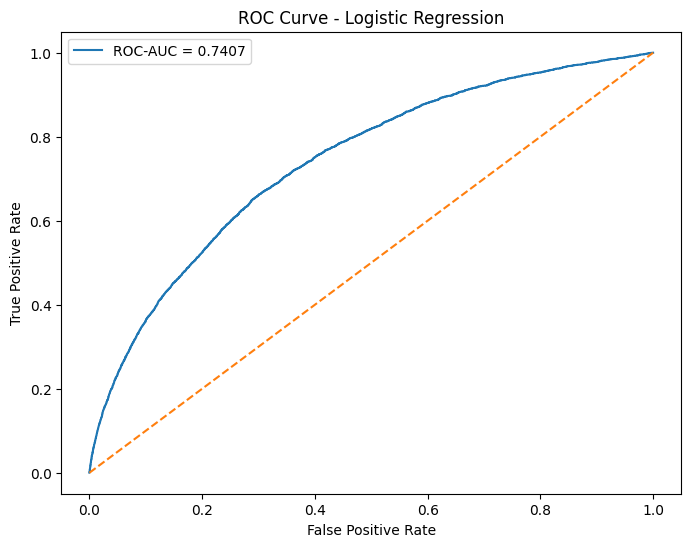

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc_score(y_test, lr_prob):.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')

plt.legend()

plt.savefig(
    '/content/drive/MyDrive/code_alpha/outputs/lr_roc_curve.png'
)

plt.show()

Feature Importance (Logistic Regression)

In [40]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

importance['Abs_Coefficient'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print(importance.head(20))

                         Feature  Coefficient  Abs_Coefficient
9                AMT_GOODS_PRICE    -0.842908         0.842908
7                     AMT_CREDIT     0.704162         0.704162
40                  EXT_SOURCE_3    -0.484245         0.484245
39                  EXT_SOURCE_2    -0.410833         0.410833
82          EMPLOYED_BIRTH_RATIO    -0.322970         0.322970
27               CNT_FAM_MEMBERS    -0.266649         0.266649
2                    CODE_GENDER     0.223157         0.223157
17                 DAYS_EMPLOYED    -0.189018         0.189018
16                    DAYS_BIRTH     0.178919         0.178919
12           NAME_EDUCATION_TYPE     0.166477         0.166477
5                   CNT_CHILDREN     0.162306         0.162306
81          ANNUITY_INCOME_RATIO     0.141904         0.141904
80           INCOME_CREDIT_RATIO    -0.132025         0.132025
13            NAME_FAMILY_STATUS    -0.121477         0.121477
3                   FLAG_OWN_CAR    -0.121429         0

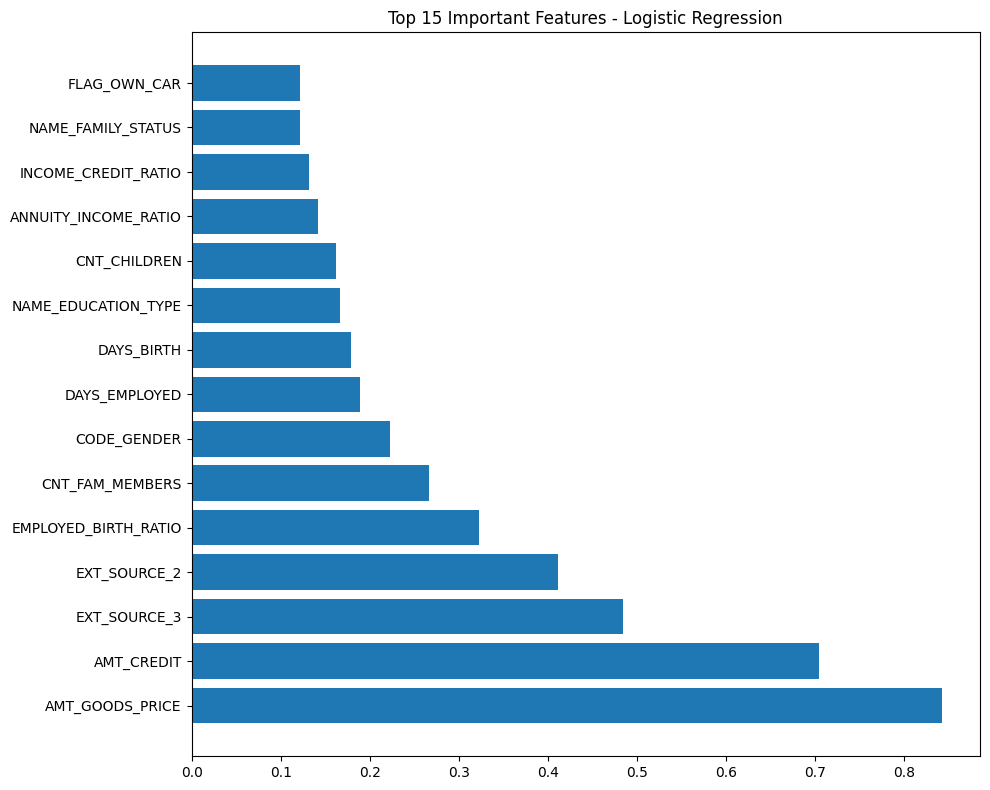

In [41]:
top_features = importance.head(15)

plt.figure(figsize=(10,8))

plt.barh(
    top_features['Feature'],
    top_features['Abs_Coefficient']
)

plt.title(
    'Top 15 Important Features - Logistic Regression'
)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/code_alpha/outputs/lr_feature_importance.png'
)

plt.show()

In [42]:
report = {
    "Accuracy": 0.6859,
    "Precision": 0.1588,
    "Recall": 0.6727,
    "F1 Score": 0.2569,
    "ROC AUC": 0.7407
}

pd.DataFrame(
    report.items(),
    columns=["Metric","Value"]
).to_csv(
    "/content/drive/MyDrive/code_alpha/outputs/lr_metrics.csv",
    index=False
)

Random Forest

Train Model

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [44]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.7787912784742208
Precision: 0.1893874029335634
Recall   : 0.5305135951661631
F1 Score : 0.2791289143220474
ROC AUC  : 0.7422943661272903


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.80      0.87     56538
           1       0.19      0.53      0.28      4965

    accuracy                           0.78     61503
   macro avg       0.57      0.67      0.57     61503
weighted avg       0.89      0.78      0.82     61503



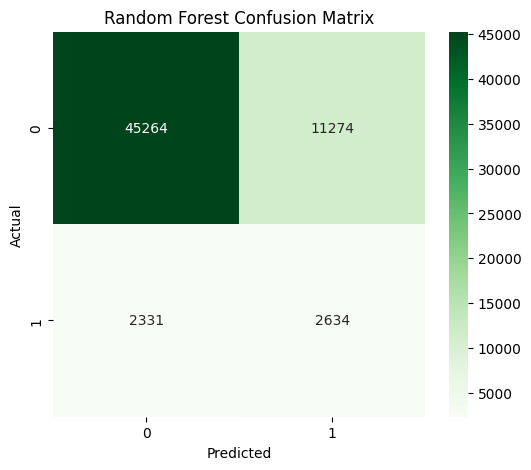

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

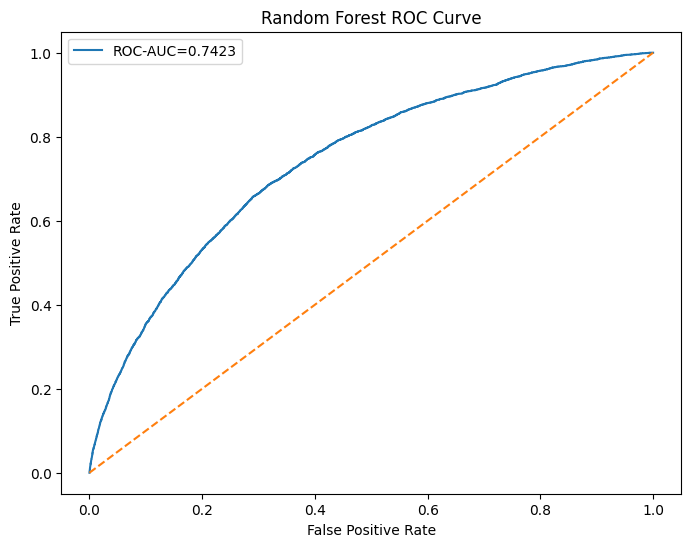

In [48]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC={roc_auc_score(y_test, rf_prob):.4f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Random Forest ROC Curve')

plt.legend()

plt.show()

Feature Importance

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

                       Feature  Importance
40                EXT_SOURCE_3    0.169033
39                EXT_SOURCE_2    0.155567
83        CREDIT_ANNUITY_RATIO    0.047518
16                  DAYS_BIRTH    0.046838
82        EMPLOYED_BIRTH_RATIO    0.038148
17               DAYS_EMPLOYED    0.037481
53      DAYS_LAST_PHONE_CHANGE    0.033592
19             DAYS_ID_PUBLISH    0.031286
9              AMT_GOODS_PRICE    0.030043
7                   AMT_CREDIT    0.029252
8                  AMT_ANNUITY    0.028245
18           DAYS_REGISTRATION    0.027447
81        ANNUITY_INCOME_RATIO    0.026650
80         INCOME_CREDIT_RATIO    0.025769
12         NAME_EDUCATION_TYPE    0.024446
15  REGION_POPULATION_RELATIVE    0.023204
0                   SK_ID_CURR    0.023034
38           ORGANIZATION_TYPE    0.018174
84    INCOME_PER_FAMILY_MEMBER    0.017741
6             AMT_INCOME_TOTAL    0.016426


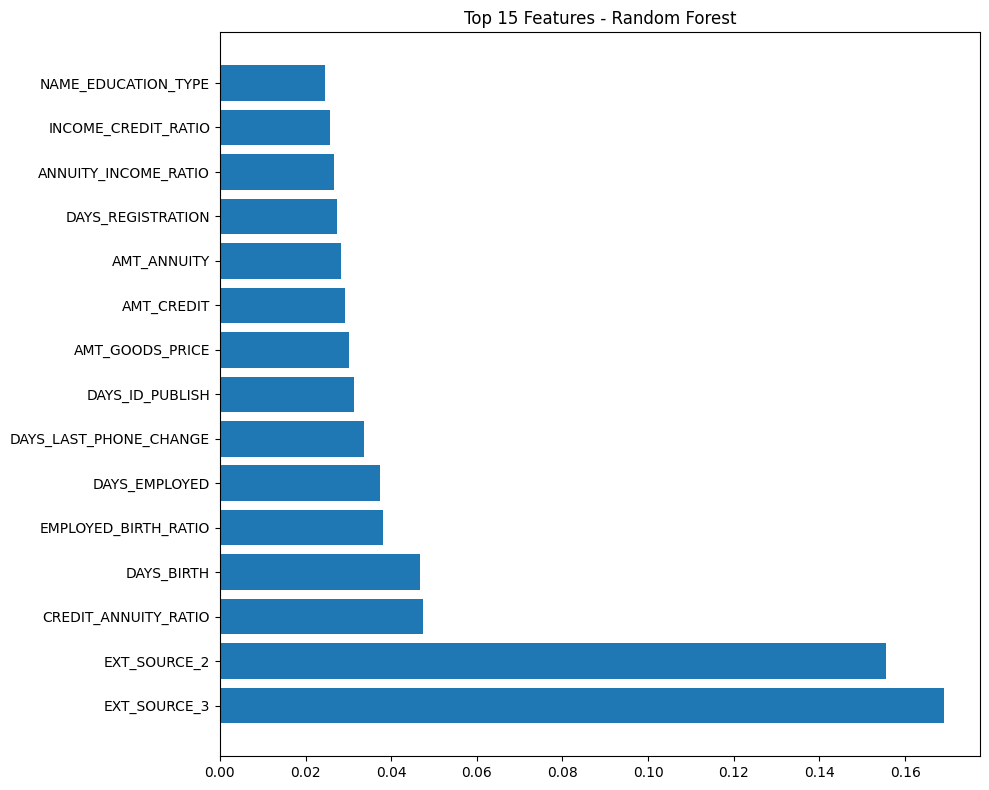

In [50]:
top_features = importance.head(15)

plt.figure(figsize=(10,8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 15 Features - Random Forest')

plt.tight_layout()

plt.show()

In [51]:
!pip install xgboost -q

Train XGBoost

In [52]:
from xgboost import XGBClassifier

scale_pos_weight = 282686 / 24825

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7273141147586296
Precision: 0.17647703606269868
Recall   : 0.648539778449144
F1 Score : 0.27745465512041706
ROC AUC  : 0.7614799813630502


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.65      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.73      0.79     61503



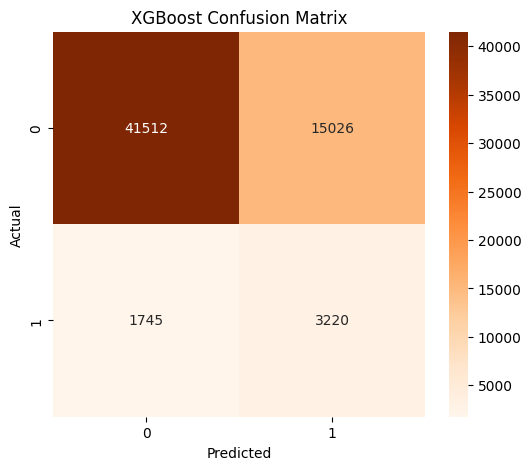

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

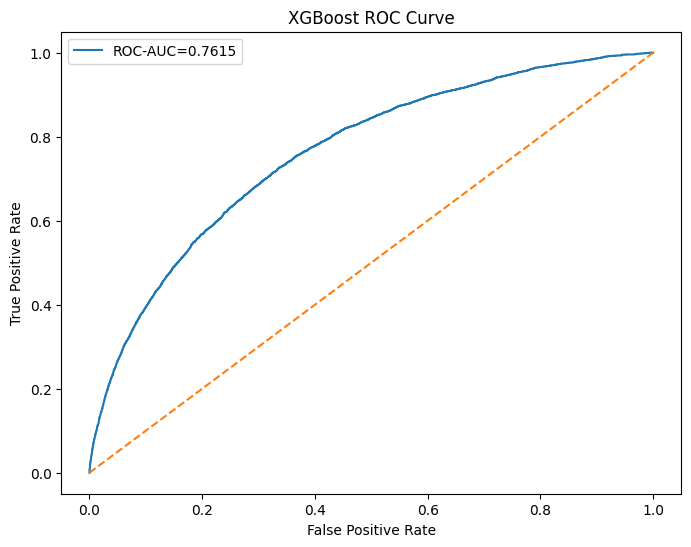

In [57]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC={roc_auc_score(y_test, xgb_prob):.4f}'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')

plt.legend()

plt.show()

In [58]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

                         Feature  Importance
40                  EXT_SOURCE_3    0.092052
39                  EXT_SOURCE_2    0.089981
12           NAME_EDUCATION_TYPE    0.072364
2                    CODE_GENDER    0.063724
3                   FLAG_OWN_CAR    0.039523
55               FLAG_DOCUMENT_3    0.038251
83          CREDIT_ANNUITY_RATIO    0.032691
16                    DAYS_BIRTH    0.026416
11              NAME_INCOME_TYPE    0.024244
9                AMT_GOODS_PRICE    0.023736
17                 DAYS_EMPLOYED    0.023273
7                     AMT_CREDIT    0.021432
13            NAME_FAMILY_STATUS    0.020331
8                    AMT_ANNUITY    0.020070
47                TOTALAREA_MODE    0.019114
41   YEARS_BEGINEXPLUATATION_AVG    0.018613
82          EMPLOYED_BIRTH_RATIO    0.018344
19               DAYS_ID_PUBLISH    0.017994
43  YEARS_BEGINEXPLUATATION_MODE    0.017931
81          ANNUITY_INCOME_RATIO    0.017841


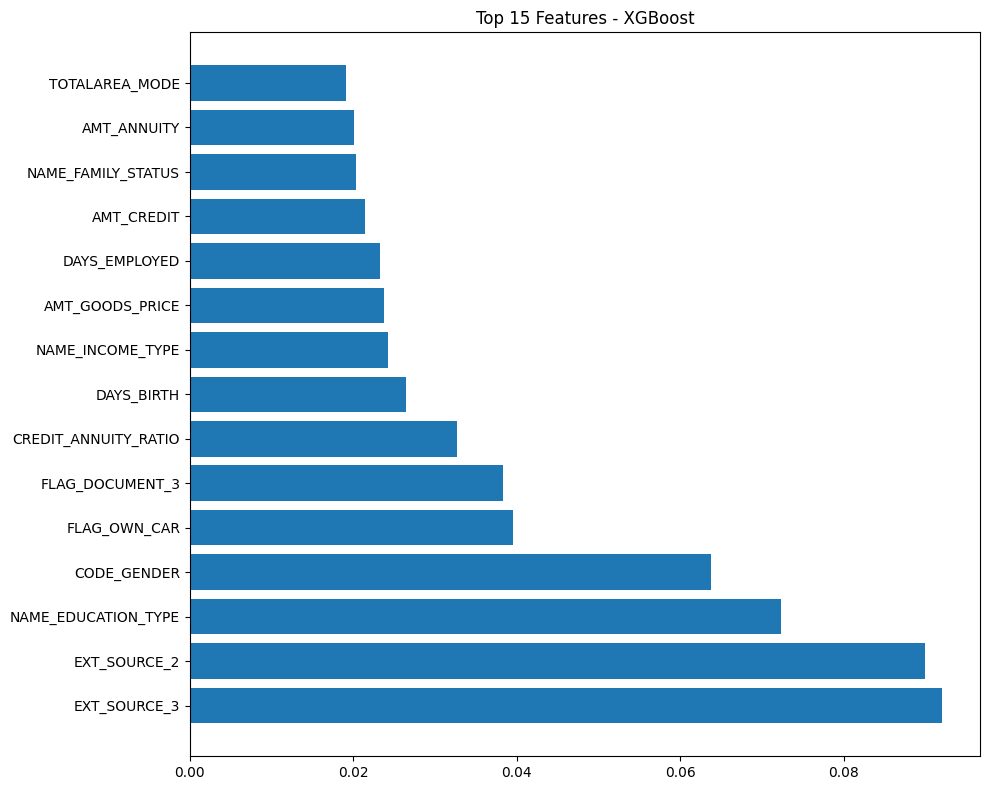

In [59]:
top_features = importance.head(15)

plt.figure(figsize=(10,8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 15 Features - XGBoost')

plt.tight_layout()

plt.show()

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("="*50)
print("XGBOOST EVALUATION")
print("="*50)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

print("\n")
print("="*50)
print("CONFUSION MATRIX")
print("="*50)

print(confusion_matrix(y_test, xgb_pred))

print("\n")
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_test, xgb_pred))

XGBOOST EVALUATION
Accuracy : 0.7273141147586296
Precision: 0.17647703606269868
Recall   : 0.648539778449144
F1 Score : 0.27745465512041706
ROC AUC  : 0.7614799813630502


CONFUSION MATRIX
[[41512 15026]
 [ 1745  3220]]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.65      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.73      0.79     61503



In [61]:
results = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
}

comparison_df = pd.DataFrame(results)

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.685902   0.158798  0.672709  0.256943  0.740705
1        Random Forest  0.778791   0.189387  0.530514  0.279129  0.742294
2              XGBoost  0.727314   0.176477  0.648540  0.277455  0.761480


Among the three models tested, XGBoost achieved the highest ROC-AUC score of 0.7615, indicating superior ability to distinguish between creditworthy and high-risk applicants. Therefore, XGBoost was selected as the final model for credit scoring.

In [62]:
import joblib

joblib.dump(
    xgb,
    '/content/drive/MyDrive/code_alpha/models/xgboost_credit_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [63]:
import os

os.listdir('/content/drive/MyDrive/code_alpha/models')

['xgboost_credit_model.pkl']

In [64]:
joblib.dump(
    scaler,
    '/content/drive/MyDrive/code_alpha/models/standard_scaler.pkl'
)

['/content/drive/MyDrive/code_alpha/models/standard_scaler.pkl']

In [65]:
joblib.dump(
    label_encoders,
    '/content/drive/MyDrive/code_alpha/models/label_encoders.pkl'
)

['/content/drive/MyDrive/code_alpha/models/label_encoders.pkl']